In [1]:
%run 00_setup.ipynb

In [2]:
RUN_ID = REFERENCE_RUN   # = 2, a execucao de referencia (a adjudicada); mude para analisar outra
ann    = load("annotations.csv", run=RUN_ID)
gold   = load("gold.csv", run=RUN_ID)
status = load("status.csv", run=RUN_ID)
fail   = load("failures.csv", run=RUN_ID)
dist   = load("pattern_distribution.csv", run=RUN_ID)
sample = load("sample.csv", run=RUN_ID)
meta   = load("meta.csv", run=RUN_ID).iloc[0].to_dict()

print(f"run {RUN_ID}: {meta['label']}  |  painel: {meta['panel']}")
print(f"{len(ann)} linhas de anotacao, {len(gold)} linhas de gold, {len(status)} linhas de estado, {len(fail)} linhas de falha")

run 2: llm_panel #2  |  painel: deepseek/deepseek-v4-flash;meta-llama/llama-3.3-70b-instruct;openai/gpt-oss-120b;qwen/qwen3-next-80b-a3b-instruct
67317 linhas de anotacao, 5000 linhas de gold, 3600 linhas de estado, 57 linhas de falha


## Análise A: concordância do painel (fiabilidade)
Medida **entre os avaliadores do painel, nunca contra a referência**. Por padrão: α (Krippendorff), κ por pares (Cohen), AC1 (Gwet) e a concordância específica P_pos / P_neg. Estas últimas resistem quando um padrão é raro, o que sucede com a maioria. (Esta análise diz respeito apenas ao painel, pelo que `PASS` não a afecta.)

In [3]:
agreement_table(ann)

,code,alpha,kappa,ac1,p_pos,p_neg,pos_votes
0,DR-1,0.445,0.416,0.992,0.427,0.996,26
1,DR-2,0.381,0.401,0.977,0.391,0.989,63
2,PE-1,0.245,0.248,0.966,0.262,0.983,79
3,PE-2,0.117,0.078,0.968,0.130,0.984,63
4,PE-3,0.207,0.144,0.990,0.212,0.995,22
5,PE-4,-0.001,0.166,0.998,0.000,0.999,3
6,PM-1,0.730,0.732,0.963,0.750,0.982,237
7,PM-2,0.259,0.359,0.988,0.262,0.994,29
8,PM-3,0.634,0.621,0.990,0.632,0.995,47
9,PM-4,0.544,0.615,0.993,0.543,0.997,25


**paradoxo de *kappa*.** Num padrão raro, é de esperar que o α (e o κ) fiquem baixos, ou mesmo negativos, enquanto o AC1 e o P_neg ficam altos. Explica-se porque a classe negativa domina, a concordância de acaso fica inflacionada e o α desce. Um α `NaN` significa que o padrão praticamente nunca foi sinalizado (sem variância, nada havendo sobre o que discordar). Convém reportá-los todos em conjunto e deixar que o P_pos sustente a leitura nos padrões raros.

### O intervalo de confiança do α, por *bootstrap*

Reamostram-se avaliações completas com reposição (as 19 decisões de cada avaliação andam sempre juntas), recalcula-se o α de cada padrão em cada réplica e tomam-se os percentis 2,5 e 97,5. Cada avaliação reamostrada recebe um identificador novo, para que as repetidas contem como observações distintas. Nos padrões com poucos votos positivos o intervalo é largo por construção.

In [4]:
B = 2000
rng = np.random.default_rng(0)
ids = ann["individualId"].unique()
codes = sorted(ann["code"].unique())
boots = {c: [] for c in codes}
for _ in range(B):
    take = pd.DataFrame({"individualId": rng.choice(ids, len(ids), replace=True)})
    take["bootId"] = range(len(take))
    boot = take.merge(ann, on="individualId", how="left")
    boot = boot.drop(columns="individualId").rename(columns={"bootId": "individualId"})
    for c in codes:
        boots[c].append(alpha(boot, c))
ic_alpha = pd.DataFrame({
    "alpha":   [alpha(ann, c) for c in codes],
    "ic_2_5":  [np.nanpercentile(boots[c], 2.5) for c in codes],
    "ic_97_5": [np.nanpercentile(boots[c], 97.5) for c in codes],
}, index=codes).round(3)
ic_alpha.sort_values("alpha", ascending=False)

,alpha,ic_2_5,ic_97_5
TM-2,0.799,-0.001,1.000
PM-1,0.730,0.659,0.791
TM-1,0.670,0.589,0.739
PM-3,0.634,0.441,0.777
PM-4,0.544,0.212,0.769
DR-1,0.445,0.163,0.655
SE-3,0.433,0.205,0.604
DR-2,0.381,0.205,0.532
PM-5,0.369,0.085,0.589
PM-6,0.333,0.332,0.333


gravado: figures/fig-concordancia-alfa-ac1.png


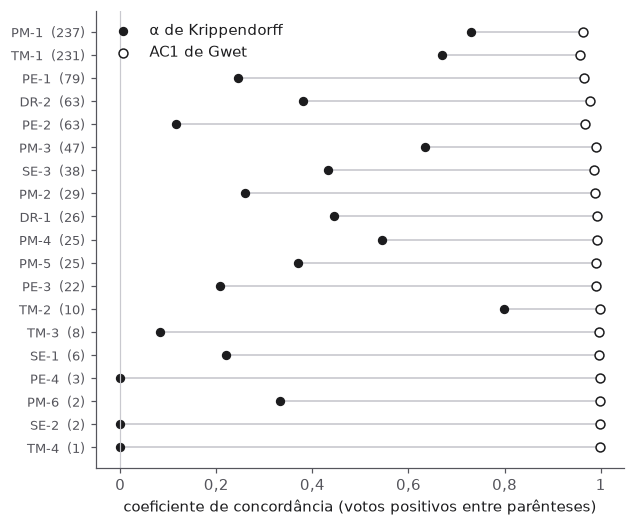

In [5]:
from matplotlib.ticker import FuncFormatter
plt = styled_plt()
t = agreement_table(ann).sort_values("pos_votes")   # mais frequentes no topo do grafico
labels = [f"{c}  ({v})" for c, v in zip(t["code"], t["pos_votes"])]
ys = range(len(t))
fig, ax = plt.subplots(figsize=(6.2, 5.4))
for y, (a, c) in enumerate(zip(t["alpha"], t["ac1"])):
    if pd.notna(a) and pd.notna(c):
        ax.plot([a, c], [y, y], color=FAINT, lw=1.1, zorder=1)
ax.scatter(t["alpha"], ys, s=26, color=INK, zorder=2, label="α de Krippendorff")
ax.scatter(t["ac1"], ys, s=34, facecolors="white", edgecolors=INK, linewidths=1.0, zorder=2, label="AC1 de Gwet")
ax.set_yticks(list(ys)); ax.set_yticklabels(labels, fontsize=8.5)
ax.axvline(0, color=FAINT, lw=0.8)
ax.set_xlabel("coeficiente de concordância (votos positivos entre parênteses)")
ax.xaxis.set_major_formatter(FuncFormatter(virgula))
ax.legend(loc="upper left")
save_fig(fig, "fig-concordancia-alfa-ac1")

## Fiabilidade entre execuções
A concordância é uma propriedade de cada configuração do painel, pelo que se mede por execução. Com um zip `?run=all`, esta secção reconstrói a tabela de concordância para as execuções textuais do desenho (1, 2, 8 e 9) e compara o α lado a lado nos padrões com sinal suficiente (pelo menos 20 votos positivos numa das execuções). O zip pode transportar outras execuções (a listagem acima mostra-as); as que não pertencem ao desenho ficam de fora dos cálculos. Tenta-se verificar se o nível de concordância observado na execução de referência é uma propriedade da tarefa ou do painel escolhido.

In [6]:
available = sorted(load("annotations.csv", run=None)["runId"].unique())
print("execucoes disponiveis no zip:", available)
RUNS = [1, 2, 8, 9]   # as execucoes do desenho factorial; ajuste a sua exportacao
tables = {run: agreement_table(load("annotations.csv", run=run)) for run in RUNS}
alpha = pd.DataFrame({f"run{run}": t.set_index("code")["alpha"] for run, t in tables.items()}).round(3)
votes = pd.DataFrame({f"votes{run}": t.set_index("code")["pos_votes"] for run, t in tables.items()})
signal = votes.max(axis=1) >= 20
pd.concat([alpha[signal], votes[signal]], axis=1).sort_values(votes.columns[0], ascending=False)

execucoes disponiveis no zip: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(6), np.int64(8), np.int64(9)]


,run1,run2,run8,run9,votes1,votes2,votes8,votes9
code,,,,,,,,
TM-1,0.764,0.670,0.568,0.779,376,231,169,238
PM-1,0.717,0.730,0.589,0.738,322,237,190,202
PE-2,0.321,0.117,0.074,0.352,163,63,60,60
DR-2,0.346,0.381,0.311,0.272,99,63,52,39
PE-3,0.381,0.207,0.140,0.293,94,22,23,49
SE-3,0.439,0.433,0.390,0.381,84,38,42,36
PE-1,0.376,0.245,0.166,0.290,82,79,83,59
PM-4,0.470,0.544,0.426,0.493,64,25,34,40
PM-2,0.503,0.259,0.121,0.441,60,29,36,18


Três leituras, com os valores da base de dados de referência. Primeiro, os painéis comerciais (runs 1 e 9) concordam mais entre si nos padrões frequentes (α de 0,72 a 0,78 no PM-1 e no TM-1) do que o painel aberto com contexto (run 8: 0,59 e 0,57), com a execução de referência (2, aberto sem contexto) entre os dois (0,73 e 0,67). Segundo, no par aberto (2→8, o mesmo painel), o contexto de jogo **baixa também a concordância**, e não apenas a validade. Terceiro, nenhuma configuração atinge o patamar satisfatório de 0,80, e as medianas do α nos padrões com sinal ficam todas entre 0,35 e 0,44, pelo que a concordância moderada é, em grande medida, uma propriedade da tarefa, e não do painel escolhido.